# Lab 1 — Parkinson's Disease Detection with Classical Machine Learning

**Course:** AI for Diagnosis of Neurodegenerative Diseases · Session 2

Dr. Alejandro Santos Díaz,

Tecnológico de Monterrey, July 2026

**Objective:** Detect Parkinson's disease (PD) from acoustic voice features using five classical
machine-learning algorithms, and rigorously compare them.

---

### Learning objectives
By the end of this lab you will be able to:
1. Load, explore and preprocess a real biomedical voice dataset.
2. Build a **leak-free** pipeline: stratified train/test split → scaling → SMOTE (training data only).
3. Train and tune **Logistic Regression, K-NN, SVM, Random Forest and XGBoost** with cross-validation.
4. Evaluate models with accuracy, balanced accuracy, ROC-AUC, confusion matrices and classification reports.
5. Interpret feature importances and discuss clinical implications.

### Prerequisites
- Python basics, pandas, matplotlib.
- The theory from **Session 1** (ML workflow, evaluation metrics, leakage & imbalance).

### Runtime
Google Colab (CPU is enough). Estimated time: **90–110 minutes** including the guided exercises.

> ⚠️ **Disclaimer.** This is an educational prototype on a small public dataset. It is **not** a clinical
> diagnostic tool and must not be used to make medical decisions.

## 1. Setup

Install the two packages that Colab does not include by default (`xgboost`, `imbalanced-learn`),
then import everything we need.

> **Key point:** we import `Pipeline` from **`imblearn`**, not `sklearn`. The imbalanced-learn pipeline
> applies SMOTE **only during `fit`** (i.e. on training folds), so resampled synthetic samples never leak
> into the validation/test data.

In [ ]:
# Packages not pre-installed on Colab
!pip install -q xgboost imbalanced-learn

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report, RocCurveDisplay)

# IMPORTANT: imblearn Pipeline so SMOTE runs only inside fit() on training folds
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup complete.")

Setup complete.


## 2. The dataset

We use the **UCI Parkinson's Disease** dataset (Little et al., 2008):
- **195 voice recordings** (rows), **23 biomedical voice features** + a `status` label.
- `status = 1` → Parkinson's, `status = 0` → healthy.
- Features measure pitch variation (jitter), amplitude variation (shimmer), harmonicity (HNR),
  and nonlinear vocal dynamics (RPDE, DFA, PPE).

It is freely downloadable as a single CSV (no account, no auth):
[UCI Parkinson's dataset](https://archive.ics.uci.edu/dataset/174/parkinsons)

**Citation:** Little, M. A. et al. *Suitability of dysphonia measurements for telemonitoring of Parkinson's disease.*
IEEE Trans. Biomed. Eng. (2008).

In [ ]:
import urllib.request

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data"
LOCAL_PATH = "parkinsons.data"
urllib.request.urlretrieve(URL, LOCAL_PATH)
print("Downloaded:", LOCAL_PATH)

df = pd.read_csv(LOCAL_PATH)
print("Shape:", df.shape)
df.head()

Downloaded: parkinsons.data
Shape: (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## 3. Exploratory data analysis (EDA)

Always look at the data before modeling: class balance, missing values, feature scales, and correlations.

In [ ]:
print("Columns:", list(df.columns))
print("\nClass balance (status: 1 = Parkinson's, 0 = healthy):")
print(df["status"].value_counts())
print("\nMissing values:", int(df.isna().sum().sum()))
print("\nFeature scales (min/max of a few columns):")
df.describe().T[["min", "max", "mean"]].head(8)

Columns: ['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

Class balance (status: 1 = Parkinson's, 0 = healthy):
status
1    147
0     48
Name: count, dtype: int64

Missing values: 0

Feature scales (min/max of a few columns):


,min,max,mean
MDVP:Fo(Hz),88.333000,260.10500,154.228641
MDVP:Fhi(Hz),102.145000,592.03000,197.104918
MDVP:Flo(Hz),65.476000,239.17000,116.324631
MDVP:Jitter(%),0.001680,0.03316,0.006220
MDVP:Jitter(Abs),0.000007,0.00026,0.000044
MDVP:RAP,0.000680,0.02144,0.003306
MDVP:PPQ,0.000920,0.01958,0.003446
Jitter:DDP,0.002040,0.06433,0.009920


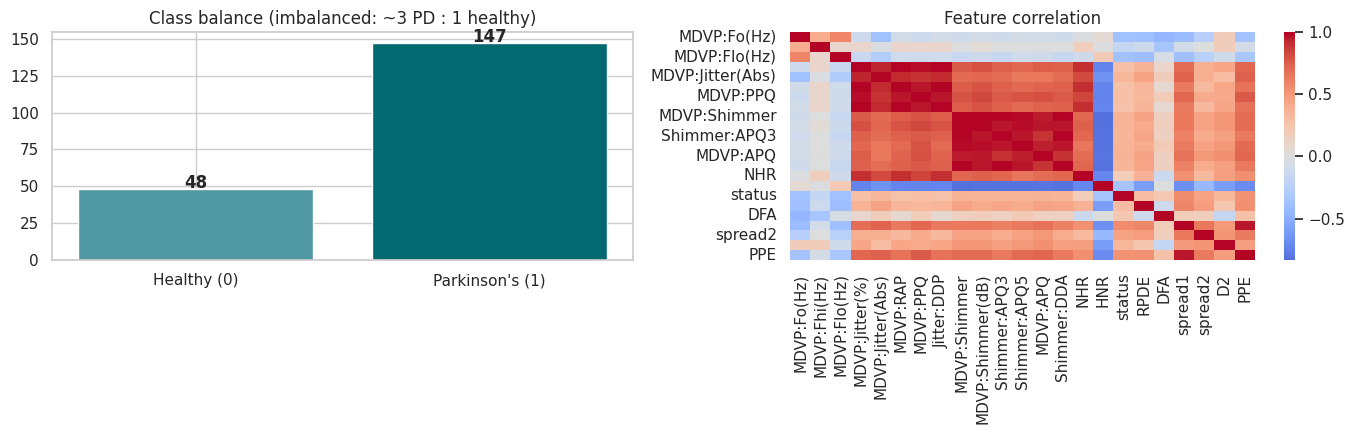

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Class balance
counts = df["status"].value_counts().sort_index()
axes[0].bar(["Healthy (0)", "Parkinson's (1)"], counts.values, color=["#4F98A3", "#01696F"])
axes[0].set_title("Class balance (imbalanced: ~3 PD : 1 healthy)")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontweight="bold")

# Correlation heatmap (drop the subject 'name' column)
num = df.drop(columns=["name"])
sns.heatmap(num.corr(), cmap="coolwarm", center=0, ax=axes[1], cbar=True)
axes[1].set_title("Feature correlation")
plt.tight_layout()
plt.show()

### Reflection
- The classes are **imbalanced** (~75% Parkinson's). Plain accuracy would be misleading, so we will also
  report **balanced accuracy** and **ROC-AUC**.
- Features are on very different scales (Hz, %, ratios) → we must **standardize** before SVM/LR.

## 4. Preprocessing — split FIRST, then scale/resample

**Golden rule to prevent leakage:** split into train/test *before* any scaling or resampling. SMOTE is then
applied **only to the training folds** inside the imbalanced-learn pipeline, so no synthetic or scaled
information from the test set contaminates training.

In [ ]:
# Features (X) and target (y). Drop the subject identifier 'name'.
X = df.drop(columns=["name", "status"])
y = df["status"]

# Stratified split keeps the PD/healthy ratio in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print("Train class balance:\n", y_train.value_counts())

Train: (146, 22)   Test: (49, 22)
Train class balance:
 status
1    110
0     36
Name: count, dtype: int64


## 5. Training pipeline and hyperparameter tuning

We define a reusable pipeline `StandardScaler → SMOTE → classifier` and a small grid of hyperparameters per
model. `GridSearchCV` with **stratified 5-fold cross-validation** (optimizing ROC-AUC) selects the best
configuration. SMOTE runs inside each CV training fold, so it never touches validation folds.

In [ ]:
def make_pipeline(model):
    """Scaler + SMOTE (train only) + classifier, all inside an imblearn Pipeline."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", model),
    ])

models = {
    "LogisticRegression": (
        LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
        {"clf__C": [0.01, 0.1, 1, 10], "clf__class_weight": [None, "balanced"]},
    ),
    "SVM": (
        SVC(probability=True, random_state=RANDOM_STATE),
        {"clf__C": [0.1, 1, 10], "clf__gamma": ["scale", "auto"], "clf__kernel": ["rbf"]},
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 8, 16],
         "clf__class_weight": [None, "balanced"]},
    ),
    "XGBoost": (
        XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
        {"clf__n_estimators": [200, 400], "clf__max_depth": [3, 6],
         "clf__learning_rate": [0.05, 0.1]},
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"clf__n_neighbors": [3, 5, 7, 11, 15], "clf__weights": ["uniform", "distance"],
         "clf__p": [1, 2]},
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_models = {}
for name, (model, grid) in models.items():
    search = GridSearchCV(make_pipeline(model), grid, scoring="roc_auc", cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    print(f"{name:20s} best CV ROC-AUC = {search.best_score_:.3f}   params = {search.best_params_}")

LogisticRegression   best CV ROC-AUC = 0.867   params = {'clf__C': 0.01, 'clf__class_weight': None}
SVM                  best CV ROC-AUC = 0.948   params = {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
RandomForest         best CV ROC-AUC = 0.955   params = {'clf__class_weight': None, 'clf__max_depth': 8, 'clf__n_estimators': 200}
XGBoost              best CV ROC-AUC = 0.965   params = {'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 400}
KNN                  best CV ROC-AUC = 0.968   params = {'clf__n_neighbors': 7, 'clf__p': 1, 'clf__weights': 'distance'}


## 6. Evaluation on the held-out test set

We report **accuracy, balanced accuracy and ROC-AUC**, plus confusion matrices and ROC curves for all four
models. The best model also gets a full classification report.

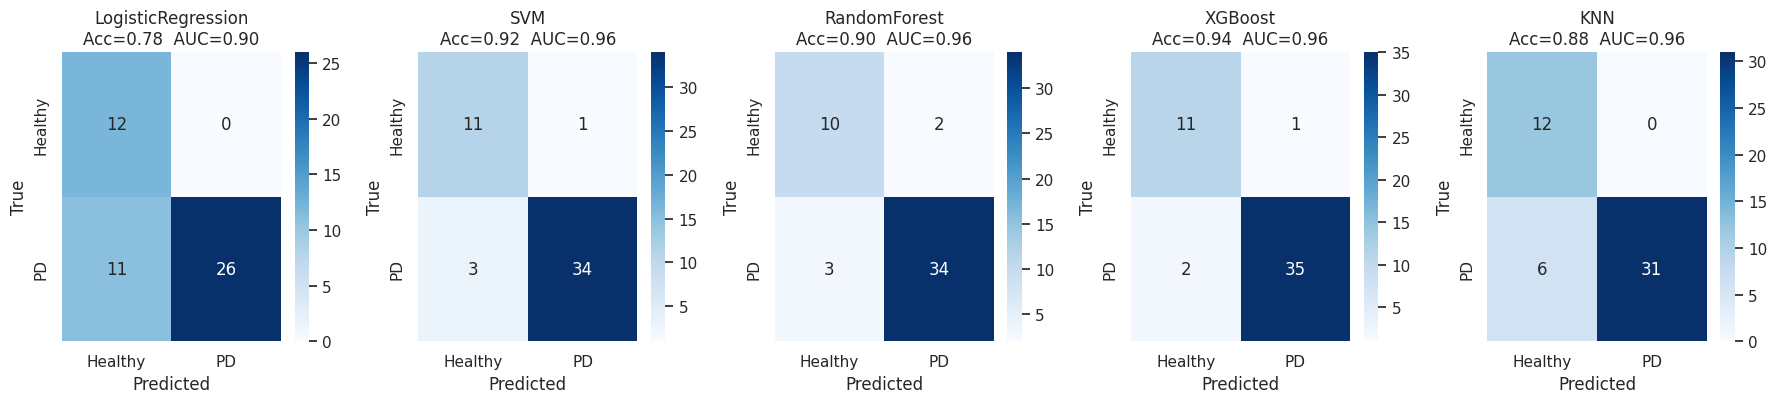

,Model,Accuracy,Balanced Acc,ROC-AUC
0,KNN,0.877551,0.918919,0.962838
1,RandomForest,0.897959,0.876126,0.961712
2,SVM,0.918367,0.917793,0.961712
3,XGBoost,0.938776,0.931306,0.961712
4,LogisticRegression,0.775510,0.851351,0.898649


In [ ]:
results = []
fig, axes = plt.subplots(1, len(best_models), figsize=(18, 4.2))
for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    results.append({"Model": name, "Accuracy": acc, "Balanced Acc": bacc, "ROC-AUC": auc})
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Healthy", "PD"], yticklabels=["Healthy", "PD"])
    ax.set_title(f"{name}\nAcc={acc:.2f}  AUC={auc:.2f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout(); plt.show()

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df

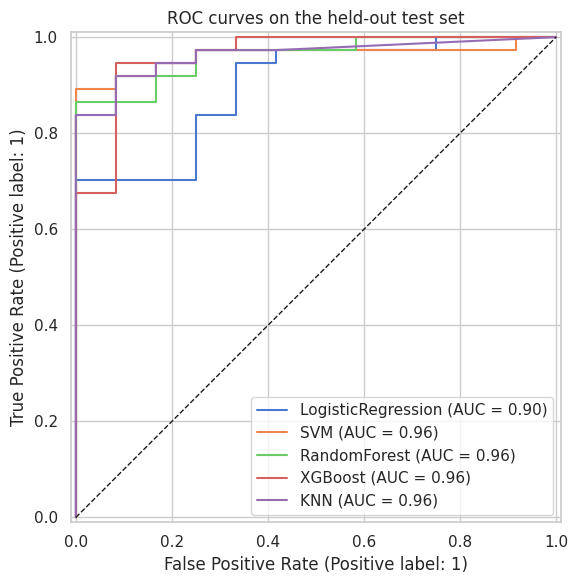

Best model: KNN

              precision    recall  f1-score   support

     Healthy       0.67      1.00      0.80        12
 Parkinson's       1.00      0.84      0.91        37

    accuracy                           0.88        49
   macro avg       0.83      0.92      0.86        49
weighted avg       0.92      0.88      0.88        49



In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in best_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC curves on the held-out test set")
plt.tight_layout(); plt.show()

# Full report for the best model
best_name = results_df.iloc[0]["Model"]
print(f"Best model: {best_name}\n")
print(classification_report(y_test, best_models[best_name].predict(X_test),
                            target_names=["Healthy", "Parkinson's"]))

## 7. Feature importance

Tree-based models expose feature importances — which voice characteristics drive the prediction? This is a
first step toward clinical interpretability (a topic we revisit with Grad-CAM in Lab 2).

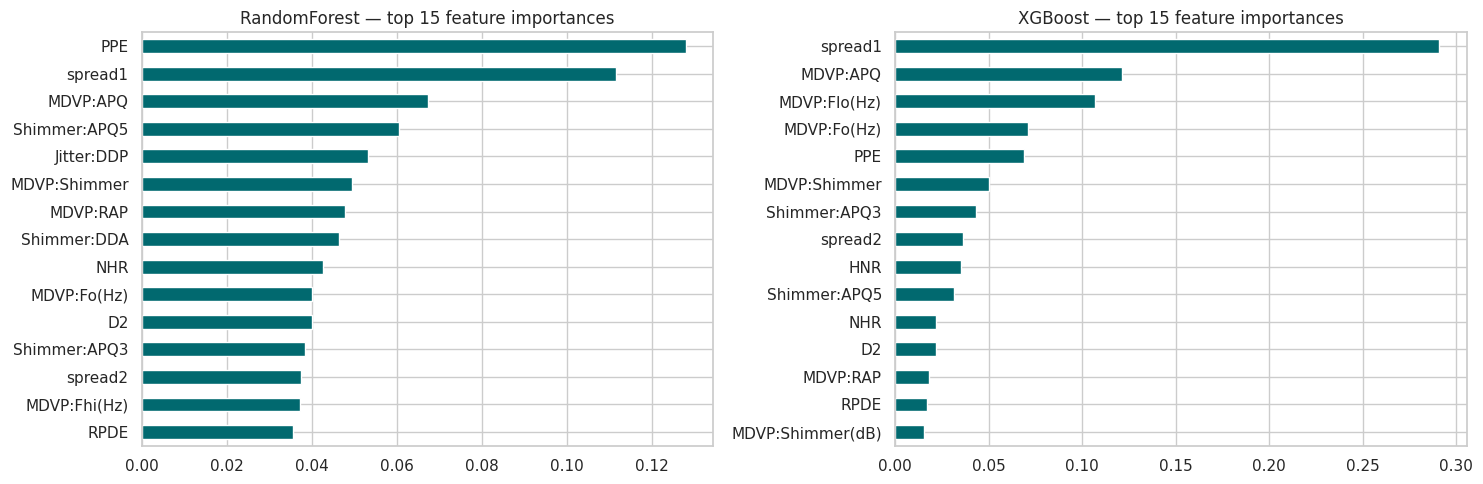

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, name in zip(axes, ["RandomForest", "XGBoost"]):
    clf = best_models[name].named_steps["clf"]
    imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values()
    imp.tail(15).plot.barh(ax=ax, color="#01696F")
    ax.set_title(f"{name} — top 15 feature importances")
plt.tight_layout(); plt.show()

## 8. Interpretation questions

Discuss in pairs / groups:

1. Which model performs best, and by how much? Is the difference likely **clinically meaningful** or within
   noise on only 49 test samples? XG Boost porque es el que minimiza los falsos negativos al máximo y solo falla en un falso positivo, además la curva ROC es cercana a 1, AUC=0.96
2. Look at the confusion matrices. Which model minimizes **false negatives** (missed Parkinson's cases)? XGBoost
   Why might that matter most in a screening setting? vale más no equivocarse en diagnosticar a quien tiene la enfermedad que a quien es sano y se diagnostica como sano
3. Which voice features are most important? Do they make physiological sense (jitter/shimmer reflect
   vocal instability typical of dysphonia in PD)? spread1 MDVP:APQ
4. What would happen if you had applied SMOTE **before** the train/test split? (Conceptually — we avoided it.) Data leakage
5. This dataset has 195 subjects but only **32 healthy**. What are the risks of trusting a high AUC here? La muestra de gente saludable no sea lo suficientemente sustancial y puede provocar que falseé el valor real de la AUC
   How would you validate the model more robustly? Con un dataset más variado, más casos saludables y con Parkinson

---

## 9. Homework — Parkinson's severity classification (a parallel exercise)

You will now apply the **same toolkit** to a **new** Parkinson's dataset on your own, with one extra twist
that teaches a critical real-world lesson about **data leakage from repeated measurements**.

### Dataset
**UCI Parkinson's Telemonitoring** dataset (Tsanas et al., 2010):
- **5,875 voice recordings** from **42 subjects** (longitudinal: many recordings per patient).
- 16 voice features + `subject#`, `age`, `sex`, `test_time`, and two regression targets
  (`motor_UPDRS`, `total_UPDRS`).
- [Dataset:Parkinson's telemonitoring](https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring)

**Citation:**  [Tsanas, A., Little, M., McSharry, P. et al. Accurate telemonitoring of Parkinson’s disease progression by non-invasive speech tests. Nat Prec (2009).](https://www.nature.com/articles/npre.2009.3920.1).

### Your tasks
1. Download and inspect the dataset (shape, columns, number of unique `subject#`).
2. Create a **binary target** by binarizing `total_UPDRS` at its median
   (`high_severity = 1` if above median, else `0`).
3. Split the data **grouped by `subject#`** so no patient appears in both train and test.
4. Reuse the four pipelines (scaler + SMOTE + LR/SVM/RF/XGBoost), tune with grouped CV, and evaluate on the
   held-out test set with accuracy, balanced accuracy, ROC-AUC and a confusion matrix.
5. **Leakage experiment:** train XGBoost on a *naive random* 80/20 split (ignoring patient grouping),
   report the test ROC-AUC, and explain why it is **artificially inflated**.
6. Answer the reflection questions in the final markdown cell.

### Deliverables
- One Colab notebook (`Homework1_<yourname>.ipynb`) with all code, outputs and a short written analysis.
- A results table comparing the 4 models (grouped split) AND the leaky XGBoost AUC, with 1–2 sentences
  interpreting the gap.

### Grading rubric (100 pts)
| Criterion | Pts |
|---|---|
| Data loading & EDA | 10 |
| Correct grouped train/test split (no patient overlap) | 20 |
| Four trained & tuned models with grouped CV | 25 |
| Evaluation (metrics + confusion matrix + comparison table) | 20 |
| Leakage experiment + correct interpretation | 15 |
| Written analysis & reflection questions | 10 |

The starter code below gives you the scaffolding — fill in every `# TODO`.

In [ ]:
# ===== HOMEWORK STARTER CODE — fill in every # TODO =====
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42

# --- TODO 1: download and inspect -----------------------------------------
URL_HW = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/telemonitoring/parkinsons_updrs.data"
urllib.request.urlretrieve(URL_HW, "parkinsons_updrs.data")
df_hw = pd.read_csv("parkinsons_updrs.data")

# TODO 1a: print shape, columns, and number of unique subjects
# print(...)
# print("Unique subjects:", df_hw["subject#"].nunique())

# --- TODO 2: create the binary target --------------------------------------
median_updrs = df_hw["total_UPDRS"].median()
df_hw["high_severity"] = (df_hw["total_UPDRS"] > median_updrs).astype(int)

# --- prepare X, y, and the grouping variable ------------------------------
# Keep subject# only for grouping; drop both regression targets.
X_hw = df_hw.drop(columns=["motor_UPDRS", "total_UPDRS", "high_severity"])
groups = X_hw["subject#"].values
y_hw = df_hw["high_severity"].values
X_hw = X_hw.drop(columns=["subject#"])

# --- TODO 3: grouped train/test split (no shared subjects) -----------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_hw, y_hw, groups))
X_train_hw, X_test_hw = X_hw.iloc[train_idx], X_hw.iloc[test_idx]
y_train_hw, y_test_hw = y_hw[train_idx], y_hw[test_idx]

# Sanity check: confirm train and test share NO subjects
train_subjects = set(groups[train_idx]); test_subjects = set(groups[test_idx])
assert len(train_subjects & test_subjects) == 0, "Patient leakage detected!"
print(f"Train: {X_train_hw.shape}  Test: {X_test_hw.shape}  (subjects: train={len(train_subjects)}, test={len(test_subjects)})")

# --- TODO 4: reuse the four pipelines + grouped CV tuning ------------------
def make_pipeline(model):
    return Pipeline([("scaler", StandardScaler()),
                     ("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", model)])

models_hw = {
    "LogisticRegression": (LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
                           {"clf__C": [0.1, 1, 10], "clf__class_weight": [None, "balanced"]}),
    "SVM": (SVC(probability=True, random_state=RANDOM_STATE),
            {"clf__C": [0.1, 1, 10], "clf__gamma": ["scale", "auto"]}),
    "RandomForest": (RandomForestClassifier(random_state=RANDOM_STATE),
                     {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 8, 16]}),
    "XGBoost": (XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
                {"clf__n_estimators": [200, 400], "clf__max_depth": [3, 6],
                 "clf__learning_rate": [0.05, 0.1]}),
}

# Hint: use GroupKFold on the TRAINING subjects for inner CV.
from sklearn.model_selection import GroupKFold
gcv = GroupKFold(n_splits=5)

best_hw = {}
for name, (model, grid) in models_hw.items():
    search = GridSearchCV(make_pipeline(model), grid, scoring="roc_auc", cv=gcv, n_jobs=-1)
    # NOTE: GroupKFold needs the groups argument in fit()
    search.fit(X_train_hw, y_train_hw, groups=groups[train_idx])
    best_hw[name] = search.best_estimator_
    print(f"{name:20s} best grouped-CV ROC-AUC = {search.best_score_:.3f}")

# TODO 4b: evaluate each model on the held-out test set
#           (accuracy, balanced accuracy, ROC-AUC, confusion matrix) and
#           build a comparison DataFrame.

# --- TODO 5: leakage experiment -------------------------------------------
# Train XGBoost on a NAIVE random 80/20 split (same patients in train and test).
from sklearn.model_selection import train_test_split as _tts
X_tr_leak, X_te_leak, y_tr_leak, y_te_leak = _tts(
    X_hw, y_hw, test_size=0.2, random_state=RANDOM_STATE)   # <-- NOT grouped!
leaky_pipe = make_pipeline(XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE,
                                          n_estimators=200, max_depth=3, learning_rate=0.1))
leaky_pipe.fit(X_tr_leak, y_tr_leak)
leaky_auc = roc_auc_score(y_te_leak, leaky_pipe.predict_proba(X_te_leak)[:, 1])
print(f"LEAKY (random split) XGBoost test ROC-AUC = {leaky_auc:.3f}")
# Compare this number to your grouped-split XGBoost AUC above.

Train: (4640, 19)  Test: (1235, 19)  (subjects: train=33, test=9)
LogisticRegression   best grouped-CV ROC-AUC = 0.633
SVM                  best grouped-CV ROC-AUC = 0.557
RandomForest         best grouped-CV ROC-AUC = 0.479
XGBoost              best grouped-CV ROC-AUC = 0.513
LEAKY (random split) XGBoost test ROC-AUC = 0.989


### TODO 6 — Reflection (answer in a markdown cell in your notebook)

1. How much higher is the **leaky** AUC than the **grouped** AUC? Explain *why* a random split inflates
   performance (hint: the model memorizes per-patient voice signatures instead of generalizing to
   unseen patients).
2. Which model generalizes best to **unseen patients**?
3. Why is patient-level splitting essential when a dataset contains repeated recordings per subject?
4. Name two other sources of leakage in medical ML besides repeated measurements.
5. If you had to deploy this model in a clinic, what additional validation would you require
   (e.g. external site, different demographics) before trusting it?

---

### Further reading
- [UCI Parkinson's (voice) dataset](https://archive.ics.uci.edu/dataset/174/parkinsons)
- [UCI Parkinson's Telemonitoring dataset](https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring)
- [imbalanced-learn — SMOTE](https://imbalanced-learn.org/stable/over_sampling.html)
- [Scikit-learn — common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)
- [XGBoost paper (Chen & Guestrin, 2016)](https://arxiv.org/abs/1603.02754)

*End of Lab 1. Next: Session 3 — Deep Learning & CNNs.*